# Imports and Setup

We start by importing the required libraries, then load the city coordinates from `cities.csv`. Finally, we compute the Euclidean distance matrix to measure the distances between all pairs of cities, which will guide the TSP route optimization.



In [7]:
import pandas as pd
import random
import numpy as np
import time
import copy
import matplotlib.pyplot as plt

# Set Random Seed (for reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Load city coordinates
cities = pd.read_csv("../data/cities.csv")
coords = cities[['X', 'Y']].values

# Compute distance matrix
dist_matrix = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))

N = len(coords) # N is the number of cities in the TSP problem



Comparison with Simulated Annealing
Lourenço, Martin & Stützle (2001) note that SA requires careful tuning of its cooling schedule, while ILS uses fewer and simpler parameters. They report that ILS usually reaches high-quality solutions faster because it intensively exploits local optima before applying perturbations. SA is described as memoryless, whereas ILS retains implicit memory through its current best local optimum. For problems like the TSP, they observe that ILS often outperforms SA in both solution quality and runtime.

Comparison with Tabu Search
According to Lourenço, Martin & Stützle (2001), 

# Section 1: Single-Member Search Algorithm

## Algorithm Selection Justification

For the single search algorithm, we selected Iterated Local Search (ILS), a variant of the Hill Climber over other approches like Simulated Annealing (SA) and Tabu Search (TS). While all three algorithm can solve the TSP problem, ILS offers distinct advantages that align with the requirements.

### Comparison with Simulated Annealing

According to Lourenço, Martin and Stützle (2001) SA requires carefull tuning of its cooling schedule, while ILS uses fewer and simpler parameters. In their experiment, they find out that ILS usually reaches high-quality solutions faster because it intensively exploits local optima before applying perturbations. For problems like the TSP, they observe that ILS often outperforms SA in both solution quality and runtime.

### Comparison with Tabu Search

Lourenço, Martin and Stützle (2001) also noted that Tabu Search relies on memory, which increases design and tuning complexity.On the other hand, ILS is simpler to implement, requiring no memory structures beyond its local search and perturbation steps. While TS can explore neighborhoods more systematically, the survey shows that well-tuned ILS often matches or exceeds TS performance across many problems, but with lower algorithmic complexity.


## Implimentation

The Hill Climber algorithm is a single-solution-driven search method.
We represent a candidate solution as a permutation of cities and iteratively improve it by swapping two cities at random, accepting the new solution if it results in a shorter total distance.
Solution class: stores the route and computes the total distance.
hill_climber function: performs the local search for a fixed number of iterations (LOOPS).

The Iterated Local Search (ILS) used here is a variant of the Hill Climber that extends its capabilities by periodically perturbing the current solution to escape local optima.
This makes it more robust for complex optimization problems like the TSP, where simple hill climbing can quickly get trapped in suboptimal solutions.

In [8]:
# ==============================
# Hyperparameters (tunable)
# ==============================
LOOPS = 1000  # Number of iterations for hill climbing
OUTER_LOOPS = 20       # number of iterations for ILS outer loop
PERTURB_STRENGTH = 2     # number of segments to perturb per iteration



# ==============================
# Solution class
# ==============================
class Solution:
    def __init__(self, route=None):
        if route is None:
            self.route = random.sample(range(N), N)
        else:
            self.route = route
        self.utility = self.evaluate()

    def evaluate(self):
        """Compute total route distance"""
        return sum(dist_matrix[self.route[i]][self.route[(i + 1) % N]] for i in range(N))

# ==============================
# Hill Climber
# ==============================
def hill_climber(start_route=None):
    current = Solution(start_route)
    best_scores = []

    improved = True
    while improved:
        improved = False
        best_distance = current.utility

        for i in range(N - 1):
            for j in range(i + 2, N):  # ensure valid 2-opt edges
                new_route = current.route.copy()
                new_route[i:j] = reversed(new_route[i:j])  # 2-opt reversal
                neighbor = Solution(new_route)

                if neighbor.utility < best_distance:
                    current = neighbor
                    best_distance = neighbor.utility
                    improved = True
                    break
            if improved:
                break

        best_scores.append(current.utility)

    return current, best_scores


# ==============================
# Perturbation for ILS
# ==============================
def perturb(route, strength=PERTURB_STRENGTH):
    new_route = route.copy()
    for _ in range(strength):
        i, j = sorted(random.sample(range(N), 2))
        new_route[i:j] = reversed(new_route[i:j])
    return new_route

# ==============================
# Iterated Local Search
# ==============================
def iterated_local_search(outer_loops=OUTER_LOOPS, perturb_strength=PERTURB_STRENGTH):
    start_time = time.time()

    best_solution, _ = hill_climber()
    best_distance = best_solution.utility
    all_best = [best_distance]

    for iteration in range(outer_loops):
        perturbed_route = perturb(best_solution.route, perturb_strength)
        new_solution, _ = hill_climber(perturbed_route)

        if new_solution.utility < best_distance:
            best_solution = new_solution
            best_distance = new_solution.utility

        all_best.append(best_distance)
        print(f"ILS Iteration {iteration+1}/{outer_loops} - Best Distance: {best_distance:.2f}")

    end_time = time.time()
    runtime = end_time - start_time

    

    return best_solution, all_best, runtime


## Single Run

In this step, we perform a single run of the Iterated Local Search (ILS) algorithm using the default parameter settings. The purpose is to evaluate the baseline performance of ILS on the TSP problem and gain initial insights into solution quality, convergence behavior, and computational time.

ILS Iteration 1/20 - Best Distance: 590.75
ILS Iteration 2/20 - Best Distance: 590.75
ILS Iteration 3/20 - Best Distance: 590.75
ILS Iteration 4/20 - Best Distance: 590.75
ILS Iteration 5/20 - Best Distance: 583.58
ILS Iteration 6/20 - Best Distance: 583.58
ILS Iteration 7/20 - Best Distance: 583.58
ILS Iteration 8/20 - Best Distance: 583.58
ILS Iteration 9/20 - Best Distance: 583.58
ILS Iteration 10/20 - Best Distance: 579.33
ILS Iteration 11/20 - Best Distance: 579.33
ILS Iteration 12/20 - Best Distance: 579.33
ILS Iteration 13/20 - Best Distance: 579.33
ILS Iteration 14/20 - Best Distance: 579.33
ILS Iteration 15/20 - Best Distance: 572.34
ILS Iteration 16/20 - Best Distance: 572.34
ILS Iteration 17/20 - Best Distance: 572.34
ILS Iteration 18/20 - Best Distance: 572.34
ILS Iteration 19/20 - Best Distance: 572.34
ILS Iteration 20/20 - Best Distance: 572.34
Best Distance: 572.34
Best Route: [40, 44, 31, 6, 35, 38, 14, 10, 15, 24, 39, 41, 18, 7, 2, 49, 28, 29, 20, 13, 11, 42, 30, 9, 48

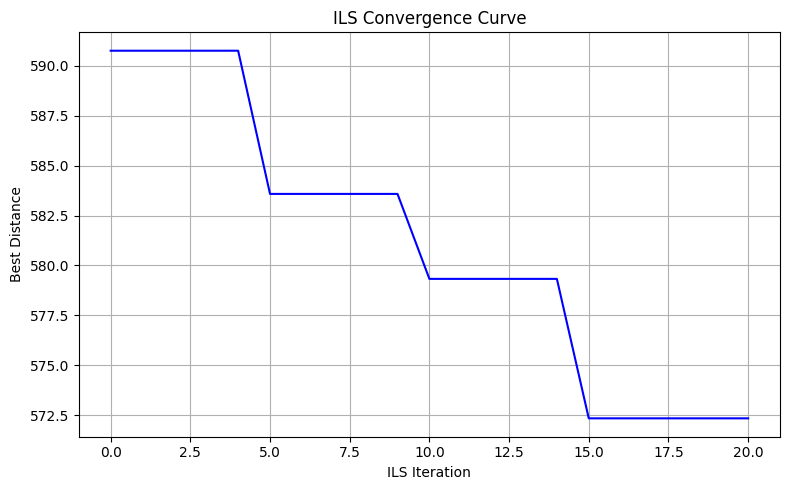

In [9]:
# ==============================
# Run ILS once and save results
# ==============================
best_solution, convergence, runtime = iterated_local_search()

# Print results
print(f"Best Distance: {best_solution.utility:.2f}")
print(f"Best Route: {best_solution.route}")
print(f"Computation Time: {runtime:.2f} seconds")

# Save results to text file
with open("../results/ils_single_run_results.txt", "w") as f:
    f.write("Single-Run ILS Result\n")
    f.write("====================\n")
    f.write(f"Best Distance: {best_solution.utility:.2f}\n")
    f.write(f"Computation Time: {runtime:.2f} seconds\n")
    f.write("Best Route (city indices in order):\n")
    f.write(" -> ".join(map(str, best_solution.route)) + "\n")

print("Single-run results saved to ils_single_run_results.txt")

# ==============================
# Plot convergence and save figure
# ==============================
plt.figure(figsize=(8,5))
plt.plot(convergence, color='blue')
plt.xlabel("ILS Iteration")
plt.ylabel("Best Distance")
plt.title("ILS Convergence Curve")
plt.grid(True)
plt.tight_layout()
plt.show()


### Single run result

The Iterated Local Search (ILS) algorithm found a best distance of 572.34 for the 50-city problem.
The computation time for this single run was approximately 1.62 seconds.
The convergence plot illustrates how the total distance decreases over iterations. The horizontal segments in the plot indicate periods where the algorithm was stuck in a local minimum, while the vertical drops correspond to the perturbation steps in ILS, which allow the algorithm to escape local optima and continue improving the solution. This demonstrates the effectiveness of ILS in overcoming local minima that a simple hill climber alone would struggle with.

## Hyperparameter tuning

After running the algorithm with the default hyperparameters, we are going to tune them in order to find the optimal configuration. Hyperparameter tuning helps improve the performance by testing different values for parameters such as the number of hill climbing iterations, perturbation strength and the number of outer loops. By exploring these parameters, we can determine which combination provides a better result

In [107]:
# ==============================
# HYPERPARAMETER TUNING: ILS
# ==============================
loops_list = [2000, 3000, 5000] # hill_climber iterations
outer_loops_list = [20, 50, 100] # ILS outer iterations
perturb_strength_list = [2, 3, 5] # number of segments to perturb

best_overall_distance = float('inf')
best_params = {}
best_solution_overall = None

for loops in loops_list:
    LOOPS = loops  # update hill climber iterations
    
    for outer_loops in outer_loops_list:
        for perturb_strength in perturb_strength_list:
            print(f"Testing LOOPS={loops}, OUTER_LOOPS={outer_loops}, PERTURB_STRENGTH={perturb_strength}...")
            
            # Run ILS with these hyperparameters
            best_solution, convergence, runtime = iterated_local_search(
                outer_loops=outer_loops, perturb_strength=perturb_strength
            )
            
            print(f"  Best distance: {best_solution.utility:.2f}")
            print(f"  Runtime: {runtime:.2f} seconds\n")
            
            # Track best overall
            if best_solution.utility < best_overall_distance:
                best_overall_distance = best_solution.utility
                best_params = {
                    "LOOPS": loops,
                    "OUTER_LOOPS": outer_loops,
                    "PERTURB_STRENGTH": perturb_strength
                }
                best_solution_overall = best_solution

print("========== BEST HYPERPARAMETERS ==========")
print(f"LOOPS: {best_params['LOOPS']}")
print(f"OUTER_LOOPS: {best_params['OUTER_LOOPS']}")
print(f"PERTURB_STRENGTH: {best_params['PERTURB_STRENGTH']}")
print(f"Best Distance Found: {best_overall_distance:.2f}")
print(f"Best Route: {best_solution_overall.route}")

with open("../results/ils_hyperparameters_best_route.txt", "w") as f:
    f.write(f"Best Distance Found: {best_overall_distance:.2f}\n")
    f.write(f"Best Hyperparameters:\n")
    f.write(f"  LOOPS: {best_params['LOOPS']}\n")
    f.write(f"  OUTER_LOOPS: {best_params['OUTER_LOOPS']}\n")
    f.write(f"  PERTURB_STRENGTH: {best_params['PERTURB_STRENGTH']}\n")
    f.write("Best Route (city indices in order):\n")
    f.write(" -> ".join(map(str, best_solution_overall.route)) + "\n")

print("Best route and hyperparameters saved to ils_best_route.txt")


Testing LOOPS=2000, OUTER_LOOPS=20, PERTURB_STRENGTH=2...
ILS Iteration 1/20 - Best Distance: 601.78
ILS Iteration 2/20 - Best Distance: 596.32
ILS Iteration 3/20 - Best Distance: 596.32
ILS Iteration 4/20 - Best Distance: 593.66
ILS Iteration 5/20 - Best Distance: 583.16
ILS Iteration 6/20 - Best Distance: 583.16
ILS Iteration 7/20 - Best Distance: 580.70
ILS Iteration 8/20 - Best Distance: 580.70
ILS Iteration 9/20 - Best Distance: 559.86
ILS Iteration 10/20 - Best Distance: 559.86
ILS Iteration 11/20 - Best Distance: 559.86
ILS Iteration 12/20 - Best Distance: 559.86
ILS Iteration 13/20 - Best Distance: 559.86
ILS Iteration 14/20 - Best Distance: 559.86
ILS Iteration 15/20 - Best Distance: 559.86
ILS Iteration 16/20 - Best Distance: 559.86
ILS Iteration 17/20 - Best Distance: 559.86
ILS Iteration 18/20 - Best Distance: 559.86
ILS Iteration 19/20 - Best Distance: 559.86
ILS Iteration 20/20 - Best Distance: 559.86
  Best distance: 559.86
  Runtime: 1.83 seconds

Testing LOOPS=2000, OU

### Hyperparameter tuning results:

| Hyperparameter       | Value  |
|---------------------|------|
| LOOPS                | 2000 |
| OUTER_LOOPS          | 50   |
| PERTURB_STRENGTH     | 2    |

The hyperparameter tuning experiment achieved a best distance of 559.86 showing that these parameters allow the ILS algorithm to efficiently find a good solutions for the 50-city TSP problem.

## Robustness experiment

Now that we have identified the best hyperparameters, we will run the ILS algorithm 10 times to evaluate its robustness. This experiment helps us understand how consistently the algorithm finds high-quality solutions.

ILS Iteration 1/50 - Best Distance: 579.54
ILS Iteration 2/50 - Best Distance: 568.55
ILS Iteration 3/50 - Best Distance: 568.55
ILS Iteration 4/50 - Best Distance: 568.55
ILS Iteration 5/50 - Best Distance: 568.55
ILS Iteration 6/50 - Best Distance: 568.55
ILS Iteration 7/50 - Best Distance: 568.55
ILS Iteration 8/50 - Best Distance: 567.77
ILS Iteration 9/50 - Best Distance: 567.77
ILS Iteration 10/50 - Best Distance: 567.77
ILS Iteration 11/50 - Best Distance: 567.77
ILS Iteration 12/50 - Best Distance: 567.77
ILS Iteration 13/50 - Best Distance: 567.77
ILS Iteration 14/50 - Best Distance: 567.77
ILS Iteration 15/50 - Best Distance: 567.77
ILS Iteration 16/50 - Best Distance: 567.77
ILS Iteration 17/50 - Best Distance: 567.77
ILS Iteration 18/50 - Best Distance: 567.77
ILS Iteration 19/50 - Best Distance: 563.02
ILS Iteration 20/50 - Best Distance: 563.02
ILS Iteration 21/50 - Best Distance: 563.02
ILS Iteration 22/50 - Best Distance: 563.02
ILS Iteration 23/50 - Best Distance: 563.

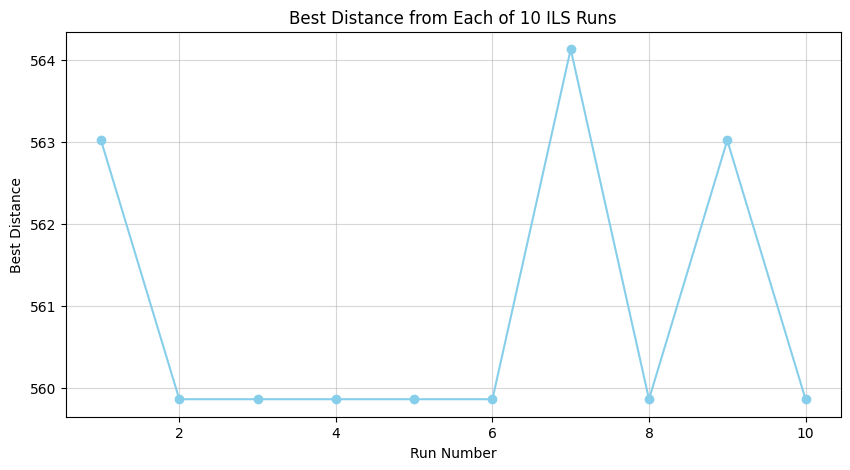

In [108]:
# ==============================
# Multi-run ILS for Robustness with Plot
# ==============================

num_runs = 10  # Number of independent runs
best_distances = []
all_solutions = []

# Use best hyperparameters from tuning
LOOPS = 2000
OUTER_LOOPS = 50
PERTURB_STRENGTH = 2

start_time = time.time()

for run in range(1, num_runs+1):
    best_solution, convergence, runtime = iterated_local_search(
        outer_loops=OUTER_LOOPS, perturb_strength=PERTURB_STRENGTH
    )
    best_distances.append(best_solution.utility)
    all_solutions.append(best_solution)
    print(f"Run {run}/{num_runs} - Best Distance: {best_solution.utility:.2f}")

end_time = time.time()
total_time = end_time - start_time

# Identify best overall solution
best_index = np.argmin(best_distances)
best_overall_solution = all_solutions[best_index]

print("\n========== Multi-Run Summary ==========")
print(f"Best Distance Found: {best_overall_solution.utility:.2f}")
print(f"Mean Distance: {np.mean(best_distances):.2f}")
print(f"Standard Deviation: {np.std(best_distances):.2f}")
print(f"Computation Time for {num_runs} runs: {total_time:.2f} seconds")
print(f"Best Route: {best_overall_solution.route}")

# ==============================
# Save results to file
# ==============================
with open("../results/ils_multi_run_results.txt", "w") as f:
    f.write("Multi-Run ILS Results\n")
    f.write("====================\n")
    f.write(f"Number of runs: {num_runs}\n")
    f.write(f"Best Distance Found: {best_overall_solution.utility:.2f}\n")
    f.write(f"Mean Distance: {np.mean(best_distances):.2f}\n")
    f.write(f"Standard Deviation: {np.std(best_distances):.2f}\n")
    f.write(f"Computation Time: {total_time:.2f} seconds\n")
    f.write("Best Route (city indices in order):\n")
    f.write(" -> ".join(map(str, best_overall_solution.route)) + "\n")

print("Multi-run results saved to ils_multi_run_results.txt")

# ==============================
# Line chart of best distances
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1, num_runs+1), best_distances, marker='o', linestyle='-', color='skyblue')
plt.xlabel("Run Number")
plt.ylabel("Best Distance")
plt.title(f"Best Distance from Each of {num_runs} ILS Runs")
plt.grid(True, alpha=0.5)
plt.show()


### Multi run result

The ILS algorithm was run 10 times using the best hyperparameters identified from the tuning experiment (LOOPS = 2000, OUTER_LOOPS = 50, PERTURB_STRENGTH = 2).

The algorithm found a best distance of 559.86 for the 50-city problem. Across the 10 runs, the mean distance was 560.92 with a standard deviation of 1.64. The best distance was achieved in 7 runs, demonstrating the algorithm’s capability to reach the global minimum or at least a high-quality local minimum.

The total computation time for all 10 runs was approximately 33.07 seconds.

## Scalability test

Next, we evaluate the scalability of our algorithm by running it on problems with different numbers of cities: 10, 20, 30, 40, and 50. This will help us understand how the algorithm’s performance and computation time change as the problem size increases.

ILS Iteration 1/20 - Best Distance: 290.31
ILS Iteration 2/20 - Best Distance: 290.31
ILS Iteration 3/20 - Best Distance: 290.31
ILS Iteration 4/20 - Best Distance: 290.31
ILS Iteration 5/20 - Best Distance: 290.31
ILS Iteration 6/20 - Best Distance: 290.31
ILS Iteration 7/20 - Best Distance: 290.31
ILS Iteration 8/20 - Best Distance: 290.31
ILS Iteration 9/20 - Best Distance: 290.31
ILS Iteration 10/20 - Best Distance: 290.31
ILS Iteration 11/20 - Best Distance: 290.31
ILS Iteration 12/20 - Best Distance: 290.31
ILS Iteration 13/20 - Best Distance: 290.31
ILS Iteration 14/20 - Best Distance: 290.31
ILS Iteration 15/20 - Best Distance: 290.31
ILS Iteration 16/20 - Best Distance: 290.31
ILS Iteration 17/20 - Best Distance: 290.31
ILS Iteration 18/20 - Best Distance: 290.31
ILS Iteration 19/20 - Best Distance: 290.31
ILS Iteration 20/20 - Best Distance: 290.31
ILS Iteration 1/20 - Best Distance: 290.31
ILS Iteration 2/20 - Best Distance: 290.31
ILS Iteration 3/20 - Best Distance: 290.31


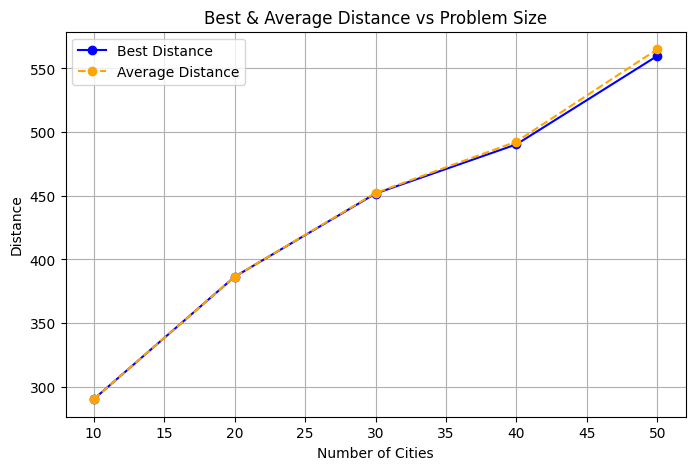

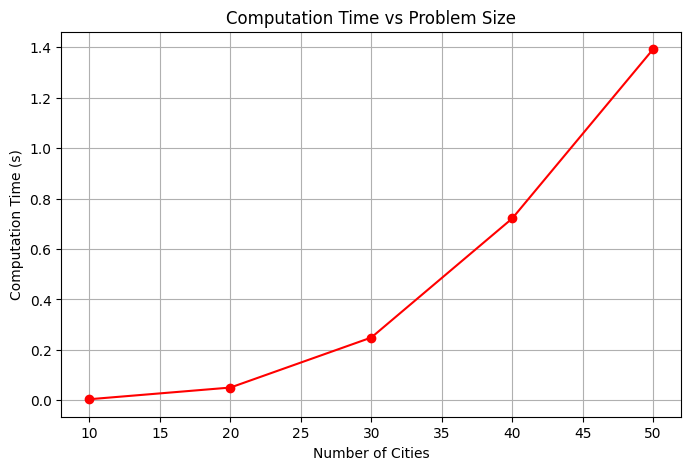

Scalability results saved to ils_scalability_results.txt


In [110]:
# ==============================
# Scalability Test: ILS with Different City Sizes
# ==============================
CITY_SIZES = [10, 20, 30, 40, 50]  # Different numbers of cities to test
NUM_RUNS = 10  # Number of runs per city size to compute average time
scalability_results = []

for size in CITY_SIZES:
    coords_subset = coords[:size]
    N = size
    dist_matrix = np.sqrt(((coords_subset[:, None, :] - coords_subset[None, :, :]) ** 2).sum(axis=2))
    
    run_times = []
    best_distances = []
    best_solutions = []
    
    for run in range(NUM_RUNS):
        start_time = time.time()
        best_solution, convergence, runtime = iterated_local_search()
        end_time = time.time()
        
        run_times.append(end_time - start_time)
        best_distances.append(best_solution.utility)
        best_solutions.append(best_solution)
    
    mean_time = np.mean(run_times)
    best_index = np.argmin(best_distances)
    best_overall = best_solutions[best_index]
    
    scalability_results.append({
        "Problem Size": size,
        "Best Distance": best_overall.utility,
        "Average Distance": np.mean(best_distances),
        "Computation Time (s)": mean_time,
        "Best Route": best_overall.route
    })
    
    

# Display scalability results
results_df = pd.DataFrame(scalability_results)
print("\nScalability Test Results:")
print(results_df)

# Plot Best & Average Distance vs Problem Size
plt.figure(figsize=(8,5))
plt.plot(results_df["Problem Size"], results_df["Best Distance"], marker='o', linestyle='-', color='blue', label='Best Distance')
plt.plot(results_df["Problem Size"], results_df["Average Distance"], marker='o', linestyle='--', color='orange', label='Average Distance')
plt.xlabel("Number of Cities")
plt.ylabel("Distance")
plt.title("Best & Average Distance vs Problem Size")
plt.legend()
plt.grid(True)
plt.show()

# Plot Computation Time vs Problem Size
plt.figure(figsize=(8,5))
plt.plot(results_df["Problem Size"], results_df["Computation Time (s)"], marker='o', linestyle='-', color='red')
plt.xlabel("Number of Cities")
plt.ylabel("Computation Time (s)")
plt.title("Computation Time vs Problem Size")
plt.grid(True)
plt.show()

# ==============================
# Save scalability results to text file
# ==============================
with open("../results/ils_scalability_results.txt", "w") as f:
    f.write("Scalability Test: ILS with Different City Sizes\n")
    f.write("=============================================\n\n")
    for result in scalability_results:
        f.write(f"Number of Cities: {result['Problem Size']}\n")
        f.write(f"Best Distance: {result['Best Distance']:.2f}\n")
        f.write(f"Average Distance: {result['Average Distance']:.2f}\n")
        f.write(f"Average Computation Time (s): {result['Computation Time (s)']:.2f}\n")
        f.write("Best Route (city indices in order):\n")
        f.write(" -> ".join(map(str, result['Best Route'])) + "\n\n")

print("Scalability results saved to ils_scalability_results.txt")


### Scalability test result

#### Small Problem Sizes (10 and 20 cities)

   - For 10 and 20 cities, the best distance is equal to the average distance.  
   - This indicates that the algorithm consistently finds the global optimum, as all runs converge to the same solution.  
   - Computation times are extremely low <= 0.05, reflecting the speed of the algorithm on small problem sizes.

#### Medium Problem Sizes (30 and 40 cities)  

As the number of cities increases, the average distance starts to diverge slightly from the best distance.  
**For 30 cities:** 
- Best distance = 451.77  
- Average distance = 452.19  
**For 40 cities:**
- Best distance = 490.39  
- Average distance = 492.56  
This divergence shows that the search space becomes larger and more complex, making it slightly harder to consistently reach the global optimum.  
Computation times remain very low (<= 0.72s).

#### Large Problem Sizes (50 cities)  
The gap between the best and average distances widens further:  
- Best distance = 559.86  
- Average distance = 565.08  
This indicates that the algorithm often finds near-optimal solutions, but not always the best.  
Computation time increases moderately (~1.39 seconds), but still fast showing the algorithm scale well for large problems.

#### Regarding the graphs
- The Best & Average Distance vs Problem Size graph visually confirms that as the number of cities increases, the average distance slightly diverges from the best distance. This illustrates that larger problems make it harder for the algorithm to consistently reach the global optimum.
- The Computation Time vs Problem Size graph shows a roughly linear growth in runtime with increasing problem size, supporting the conclusion that the ILS algorithm scales efficiently.

## Conclusion

ILS is highly effective for small TSP problems, consistently reaching the global minimum.
As the problem size grows, the search space complexity increases, and the algorithm tends to find near-optimal solutions rather than the exact global minimum.
Computation time grows modestly with problem size, demonstrating excellent scalability and efficiency.
Overall, the ILS algorithm shows strong performance across small and medium TSP instances and remains practical even for larger problems, although exact optimality becomes less certain as problem complexity increases.


# Section 2: Evolutionary Algorithm

## Genetic Algorithm

In this section, we implement a Genetic Algorithm (GA) to solve the Traveling Salesman Problem (TSP). 
The GA maintains a population of candidate tours, each represented as a permutation of city indices. 
Across generations, the population evolves through:

- **Selection** (tournament selection): chooses high-quality tours while preserving diversity.
- **Crossover** (Ordered Crossover, OX): combines parts of two parent tours to create valid offspring.
- **Mutation** (swap mutation): introduces small random changes to avoid premature convergence.
- **Elitism**: ensures the best solution is preserved each generation.

This approach allows the algorithm to balance exploration and exploitation, making it suitable for generating high-quality TSP solutions across varying problem sizes. In the cells below, we implement each component of the GA and track its convergence over multiple generations.



## Implimentation

The GA begins by defining an Individual class that represents a potential TSP solution. Each individual contains:

- gene: A permutation array representing the order of city visits
- fitness: The total route distance (to be minimized)

### Fitness Evaluation

The total_distance(ind) function calculates the fitness of an individual by summing distances between consecutive cities in the route and adding the return distance to the starting city.

### Selection with Elitism

The selection(population, elite_size=2) function implements:
Elitism: Preserves the top elite_size fittest individuals unchanged
Tournament Selection: For remaining population slots, conducts pairwise tournaments between randomly selected individuals, choosing the fitter one

### Genetic Operators

- Crossover: crossover(parents) implements Ordered Crossover (OX) which preserves relative ordering from parents while creating valid permutations
- Mutation: mutation(offspring, MUTRATE=0.1) applies swap mutation with 10% probability, exchanging two random cities in the route

In [88]:
# =========================
# Individual Representation
# =========================
class Individual:
    def __init__(self, gene):
        self.gene = gene
        self.fitness = 0

# =========================
# Fitness Function
# =========================
def total_distance(ind):
    route = ind.gene
    dist = sum(dist_matrix[route[i], route[i+1]] for i in range(len(route)-1))
    dist += dist_matrix[route[-1], route[0]]  # Return to start
    return dist

# =========================
# Selection (Tournament)
# =========================
def selection(population, elite_size=2):  
    P = len(population)
    new_pop = []
    # Sort and keep the best individuals
    population.sort(key=lambda x: x.fitness)
    for i in range(elite_size):
        new_pop.append(copy.deepcopy(population[i]))
    
    # Original tournament selection for the rest
    for _ in range(P - elite_size): 
        i1, i2 = random.sample(range(P), 2)
        winner = population[i1] if population[i1].fitness < population[i2].fitness else population[i2]
        new_pop.append(copy.deepcopy(winner))
    
    return new_pop

# =========================
# Crossover (Ordered Crossover)
# =========================
def crossover(parents):
    P = len(parents)
    N = len(parents[0].gene)
    offspring = []
    for i in range(0, P, 2):
        p1, p2 = parents[i], parents[i+1]
        a, b = sorted(random.sample(range(N), 2))
        child1_gene = [None]*N
        child2_gene = [None]*N
        child1_gene[a:b] = p1.gene[a:b]
        child2_gene[a:b] = p2.gene[a:b]
        def fill_remaining(child, parent):
            parent_cities = [c for c in parent.gene if c not in child]
            return [c if c is not None else parent_cities.pop(0) for c in child]
        child1_gene = fill_remaining(child1_gene, p2)
        child2_gene = fill_remaining(child2_gene, p1)
        offspring.append(Individual(child1_gene))
        offspring.append(Individual(child2_gene))
    return offspring

# =========================
# Mutation (Swap)
# =========================
def mutation(offspring, MUTRATE=0.1):
    N = len(offspring[0].gene)
    for ind in offspring:
        if random.random() < MUTRATE:
            a, b = random.sample(range(N), 2)
            ind.gene[a], ind.gene[b] = ind.gene[b], ind.gene[a]
    return offspring


## Single Run

In this step, we perform a single run of the GA algorithm using the default parameter settings. The purpose is to evaluate the baseline performance of GA on the TSP problem and gain initial insights into solution quality, convergence behavior, and computational time.

Before we perform the GA operators, we select the best individuals as elites. Then we perform selection, crossover, and mutation without including these elites because we want to preserve them. After applying the operators, we insert the elites back into the population and pass them to the next generation. The reason we do not alter the elites is to avoid breaking potentially optimal solutions. We repeat this process for each generation.

Gen 0: Current = 2296.65, Average = 2617.06, All-time = 2246.94
Gen 50: Current = 1408.46, Average = 1813.20, All-time = 1365.60
Gen 100: Current = 1010.18, Average = 1207.98, All-time = 998.92
Gen 150: Current = 802.52, Average = 820.98, All-time = 802.52
Gen 200: Current = 773.99, Average = 820.47, All-time = 773.99
Gen 250: Current = 763.86, Average = 777.76, All-time = 763.86
Gen 300: Current = 719.96, Average = 736.07, All-time = 719.96
Gen 350: Current = 718.58, Average = 727.96, All-time = 718.58

=== GA Results ===
All-time best distance: 718.58
Final generation best: 735.84
Best route: [18, 49, 29, 28, 2, 7, 30, 9, 48, 31, 6, 35, 38, 14, 10, 15, 24, 19, 47, 46, 44, 40, 25, 17, 26, 37, 43, 1, 4, 27, 0, 16, 21, 36, 45, 20, 13, 23, 8, 32, 22, 33, 3, 5, 34, 12, 11, 42, 39, 41]
Computation time: 2.54 seconds


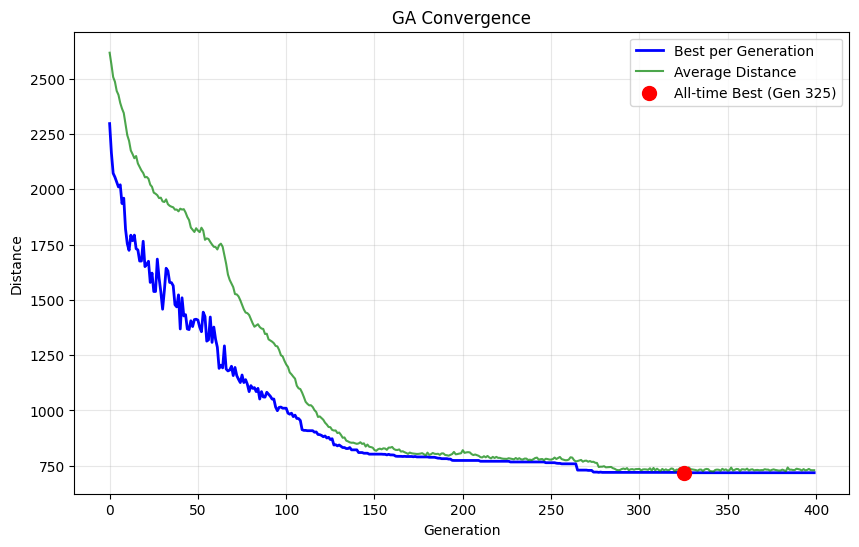

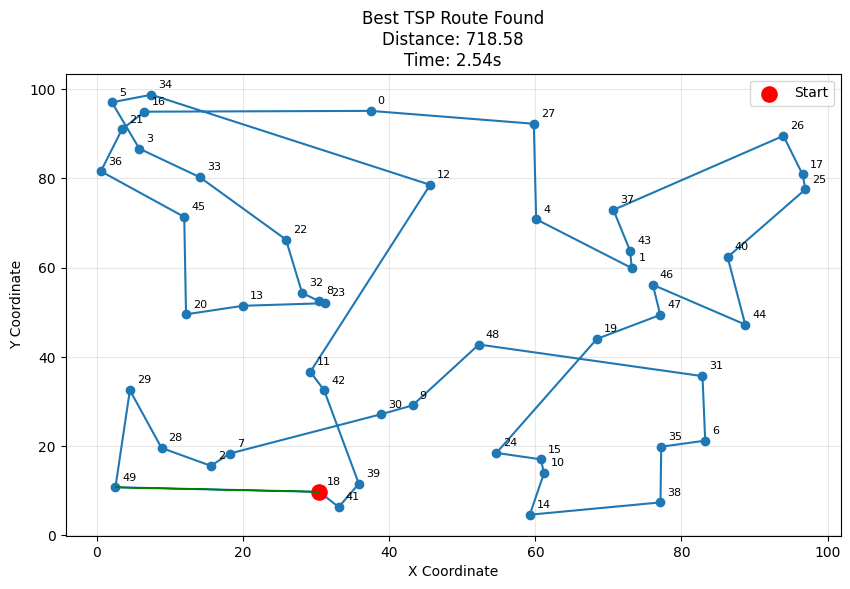

In [93]:
# =========================
# GA Parameters
# =========================
P = 200           # Population size
MUTRATE = 0.1     # Mutation rate
ELITE_SIZE = 2    # Add this constant
maxGeneration = 400

# =========================
# Initialize Population
# =========================
population = []
for _ in range(P):
    gene = random.sample(range(N), N)
    ind = Individual(gene)
    ind.fitness = total_distance(ind)
    population.append(ind)

# =========================
# GA Main Loop
# =========================
bestFitness = []
averageFitness = []
worstFitness = []

# Track all-time best
all_time_best = None
all_time_best_fitness = float('inf')

start_time = time.time()

for gen in range(maxGeneration):

    # 1. Evaluate population
    for ind in population:
        ind.fitness = total_distance(ind)

    # 2. Track all-time best
    current_best = min(population, key=lambda x: x.fitness)
    if current_best.fitness < all_time_best_fitness:
        all_time_best = copy.deepcopy(current_best)
        all_time_best_fitness = current_best.fitness

    # 3. Extract elites (best ELITE_SIZE individuals)
    elites = sorted(population, key=lambda x: x.fitness)[:ELITE_SIZE]
    elites = [copy.deepcopy(e) for e in elites]

    # 4. Selection (do NOT include elites)
    parents = selection(population, elite_size=0)

    # 5. Crossover → offspring
    offspring = crossover(parents)

    # 6. Mutation
    offspring = mutation(offspring, MUTRATE)

    # 7. Evaluate offspring (before elitism insertion)
    for ind in offspring:
        ind.fitness = total_distance(ind)

    # 8. Insert elites back: replace worst ELITE_SIZE individuals
    offspring_sorted = sorted(offspring, key=lambda x: x.fitness)
    offspring_sorted[-ELITE_SIZE:] = elites  # replace worst ones

    # 9. New population
    population = offspring_sorted

    # 10. Record statistics
    best = population[0]  # already sorted
    avg = np.mean([ind.fitness for ind in population])
    worst = population[-1]

    bestFitness.append(best.fitness)
    averageFitness.append(avg)
    worstFitness.append(worst.fitness)

    # 11. Progress logs
    if gen % 50 == 0:
        print(f"Gen {gen}: Current = {best.fitness:.2f}, "
              f"Average = {avg:.2f}, All-time = {all_time_best_fitness:.2f}")


end_time = time.time()
computation_time = end_time - start_time

# =========================
# Display Results (USE ALL-TIME BEST!)
# =========================
print(f"\n=== GA Results ===")
print(f"All-time best distance: {all_time_best_fitness:.2f}")
print(f"Final generation best: {best_solution.fitness:.2f}")
if all_time_best:
    print("Best route:", all_time_best.gene)
print(f"Computation time: {computation_time:.2f} seconds")
plt.figure(figsize=(10,6))
plt.plot(bestFitness, label='Best per Generation', color='blue', linewidth=2)
plt.plot(averageFitness, label='Average Distance', color='green', alpha=0.7, linewidth=1.5)

# Find when all-time best was discovered
if all_time_best_fitness in bestFitness:
    gen_found = bestFitness.index(all_time_best_fitness)
    plt.scatter(gen_found, all_time_best_fitness, color='red', s=100, 
                zorder=5, label=f'All-time Best (Gen {gen_found})')
else:
    plt.axhline(y=all_time_best_fitness, color='red', linestyle='--', 
               linewidth=1.5, alpha=0.7, label=f'All-time Best ({all_time_best_fitness:.2f})')

plt.xlabel('Generation')
plt.ylabel('Distance')
plt.title(f'GA Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# Plot Best Route (USE ALL-TIME BEST!)
# =========================
if all_time_best:
    best_route = all_time_best.gene + [all_time_best.gene[0]]
    x = [coords[i][0] for i in best_route]
    y = [coords[i][1] for i in best_route]
    
    plt.figure(figsize=(10,6))
    plt.plot(x, y, marker='o', linestyle='-', markersize=6)
    plt.title(f'Best TSP Route Found\nDistance: {all_time_best_fitness:.2f}\nTime: {computation_time:.2f}s')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True, alpha=0.3)
    
    for i, city_index in enumerate(best_route[:-1]):
        plt.annotate(str(city_index), (coords[city_index][0], coords[city_index][1]),
                     textcoords="offset points", xytext=(5,5), fontsize=8, color='black')
    
    first_city = best_route[0]
    plt.scatter(coords[first_city][0], coords[first_city][1], color='red', s=120, zorder=5, label='Start')
    
    second_city = best_route[1]
    plt.arrow(coords[first_city][0], coords[first_city][1],
              coords[second_city][0] - coords[first_city][0],
              coords[second_city][1] - coords[first_city][1],
              color='green', width=0.002, head_width=0.03, length_includes_head=True, zorder=6)
    
    plt.legend()
    plt.show()

# =========================
# Save GA Results (SAVE ALL-TIME BEST!)
# =========================
with open("../results/ga_single_run_results.txt", "w") as f:
    f.write("Genetic Algorithm (GA) Single Run Results\n")
    f.write("=========================================\n\n")
    f.write(f"Population size: {P}\n")
    f.write(f"Mutation rate: {MUTRATE}\n")
    f.write(f"Elite size: {ELITE_SIZE}\n")
    f.write(f"Generations: {maxGeneration}\n")
    f.write(f"Total computation time: {computation_time:.2f} seconds\n\n")
    
    f.write(f"All-time best distance found: {all_time_best_fitness:.2f}\n")
    f.write(f"Final generation best distance: {best_solution.fitness:.2f}\n")
    f.write("Best route (city indices in order):\n")
    if all_time_best:
        f.write(" -> ".join(map(str, all_time_best.gene)) + "\n\n")

### Single run result

The GA algorithm found a best distance of 718.58 for the 50-city problem.
The computation time for this single run was approximately 2.54 seconds.
The convergence plot illustrates how the total distance decreases over iterations. The algorithm gradually improve over time and does not get trapped in to a local minima. This demonstrates the effectiveness of GA to to gradually improve the solution. The all best found in generation 325 show the ability of Elitism to preserve good solution accross all generations.

## Hyperparameter tuning

After establishing baseline performance with default parameters, we conduct systematic hyperparameter tuning to identify optimal configurations. This process finds the best combinations that maximize the solution quality and efficiency.

In [95]:
# ==============================
# HYPERPARAMETER TUNING: GENETIC ALGORITHM (FIXED)
# ==============================
population_sizes = [100, 150, 200]
mutation_rates = [0.1, 0.2, 0.3]
generation_counts = [100, 300, 500]
ELITE_SIZE = 2  # ADD THIS!

best_overall_distance = float('inf')
best_params = {}
best_solution_overall = None

for P in population_sizes:
    for MUTRATE in mutation_rates:
        for maxGeneration in generation_counts:
            print(f"Testing P={P}, MUTRATE={MUTRATE}, GENERATIONS={maxGeneration}...")

            # Initialize population
            population = [Individual(random.sample(range(N), N)) for _ in range(P)]
            for ind in population:
                ind.fitness = total_distance(ind)

            # Track all-time best
            all_time_best = None
            all_time_best_fitness = float('inf')
            
            # Start timing
            start_time = time.time()

            # GA evolution loop (USE SAME LOGIC AS SINGLE RUN!)
            for gen in range(maxGeneration):
                # 1. Evaluate
                for ind in population:
                    ind.fitness = total_distance(ind)
                
                # 2. Track all-time best
                current_best = min(population, key=lambda x: x.fitness)
                if current_best.fitness < all_time_best_fitness:
                    all_time_best = copy.deepcopy(current_best)
                    all_time_best_fitness = current_best.fitness
                
                # 3. Extract elites
                elites = sorted(population, key=lambda x: x.fitness)[:ELITE_SIZE]
                elites = [copy.deepcopy(e) for e in elites]
                
                # 4. Selection (do NOT include elites)
                parents = selection(population, elite_size=0)
                
                # 5. Crossover → offspring
                offspring = crossover(parents)
                
                # 6. Mutation
                offspring = mutation(offspring, MUTRATE)
                
                # 7. Evaluate offspring
                for ind in offspring:
                    ind.fitness = total_distance(ind)
                
                # 8. Insert elites back
                offspring_sorted = sorted(offspring, key=lambda x: x.fitness)
                offspring_sorted[-ELITE_SIZE:] = elites
                
                # 9. New population
                population = offspring_sorted

            # End timing
            end_time = time.time()
            computation_time = end_time - start_time

            # Use all-time best for evaluation
            final_distance = all_time_best_fitness if all_time_best else float('inf')
            print(f"  Best distance: {final_distance:.2f}")
            print(f"  Runtime: {computation_time:.2f} seconds\n")
            
            # Track best overall configuration
            if final_distance < best_overall_distance:
                best_overall_distance = final_distance
                best_params = {
                    "P": P,
                    "MUTRATE": MUTRATE,
                    "GENERATIONS": maxGeneration
                }
                best_solution_overall = all_time_best

# ==============================
# Display Best Hyperparameters
# ==============================
print("========== BEST HYPERPARAMETERS ==========")
print(f"Population Size (P): {best_params['P']}")
print(f"Mutation Rate (MUTRATE): {best_params['MUTRATE']}")
print(f"Generations: {best_params['GENERATIONS']}")
print(f"Best Distance Found: {best_overall_distance:.2f}")
if best_solution_overall:
    print(f"Best Route: {best_solution_overall.gene}")

# ==============================
# Save Results to Text File 
# ==============================
with open("../results/ga_hyperparameters_best_route.txt", "w") as f:
    f.write("Genetic Algorithm - Hyperparameter Tuning Results\n")
    f.write("===============================================\n\n")
    f.write(f"Best Distance Found: {best_overall_distance:.2f}\n\n")
    f.write("Best Hyperparameters:\n")
    f.write(f"  Population Size (P): {best_params['P']}\n")
    f.write(f"  Mutation Rate (MUTRATE): {best_params['MUTRATE']}\n")
    f.write(f"  Generations: {best_params['GENERATIONS']}\n")
    f.write(f"  Elite Size: {ELITE_SIZE}\n\n")
    f.write("Best Route (city indices in order):\n")
    if best_solution_overall:
        f.write(" -> ".join(map(str, best_solution_overall.gene)) + "\n")

print("Best route and hyperparameters saved to ga_hyperparameters_best_route.txt")

Testing P=100, MUTRATE=0.1, GENERATIONS=100...
  Best distance: 1177.37
  Runtime: 0.36 seconds

Testing P=100, MUTRATE=0.1, GENERATIONS=300...
  Best distance: 921.98
  Runtime: 0.96 seconds

Testing P=100, MUTRATE=0.1, GENERATIONS=500...
  Best distance: 861.22
  Runtime: 1.57 seconds

Testing P=100, MUTRATE=0.2, GENERATIONS=100...
  Best distance: 1079.52
  Runtime: 0.31 seconds

Testing P=100, MUTRATE=0.2, GENERATIONS=300...
  Best distance: 736.35
  Runtime: 0.94 seconds

Testing P=100, MUTRATE=0.2, GENERATIONS=500...
  Best distance: 706.50
  Runtime: 1.59 seconds

Testing P=100, MUTRATE=0.3, GENERATIONS=100...
  Best distance: 1063.42
  Runtime: 0.31 seconds

Testing P=100, MUTRATE=0.3, GENERATIONS=300...
  Best distance: 778.08
  Runtime: 0.94 seconds

Testing P=100, MUTRATE=0.3, GENERATIONS=500...
  Best distance: 719.90
  Runtime: 1.57 seconds

Testing P=150, MUTRATE=0.1, GENERATIONS=100...
  Best distance: 974.18
  Runtime: 0.47 seconds

Testing P=150, MUTRATE=0.1, GENERATIO

### Hyperparameter tuning results:

| Hyperparameter    | Value |
|-------------------|-------|
| P                 | 200   |
| MUTRATE           | 0.1   |
| maxGeneration     | 500   |

The hyperparameter tuning experiment achieved a best distance of 660.46 showing that these parameters allow the GA to find a near optimal solution.

## Robustness experiment

Now that we have identified the best hyperparameters, we will run the GA algorithm 10 times to evaluate its robustness. This experiment helps us understand how consistently the algorithm finds high-quality solutions.

Run 1: Best Distance = 729.55, Computation Time = 3.16 seconds
Run 2: Best Distance = 648.04, Computation Time = 3.09 seconds
Run 3: Best Distance = 840.66, Computation Time = 3.17 seconds
Run 4: Best Distance = 760.77, Computation Time = 3.10 seconds
Run 5: Best Distance = 784.12, Computation Time = 3.11 seconds
Run 6: Best Distance = 732.96, Computation Time = 3.12 seconds
Run 7: Best Distance = 731.41, Computation Time = 3.29 seconds
Run 8: Best Distance = 759.91, Computation Time = 3.25 seconds
Run 9: Best Distance = 777.82, Computation Time = 3.25 seconds
Run 10: Best Distance = 817.91, Computation Time = 3.26 seconds

Multi-run GA statistics:
Mean best distance: 758.32
Std deviation: 50.74
Best distance overall: 648.04
Worst distance overall: 840.66
Mean computation time per run: 3.18 seconds
Total experiment time (all 10 runs): 31.83 seconds

Multi-run results saved to '../results/ga_multi_run_results.txt'


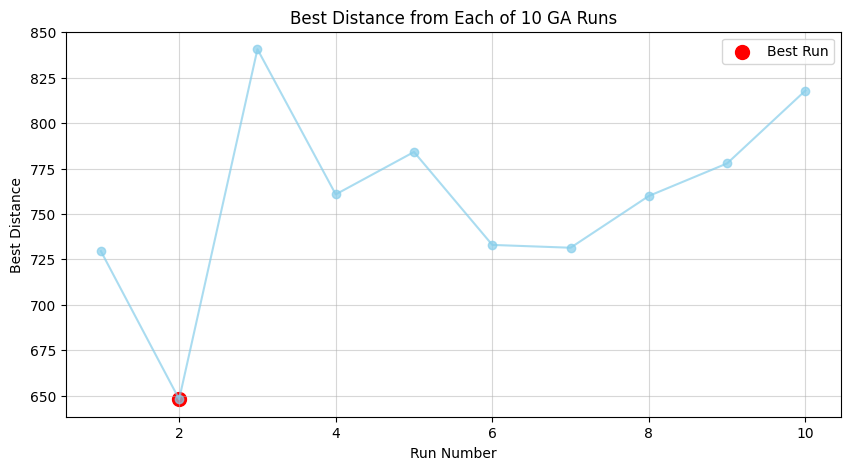

In [111]:
# =========================
# GA Parameters
# =========================
P = 200
MUTRATE = 0.1
ELITE_SIZE = 2  # ADD THIS!
maxGeneration = 500
num_runs = 10  # Number of independent GA runs

# =========================
# Multi-Run GA
# =========================
best_distances = []
all_bestFitness = []
run_times = []
all_all_time_bests = []  # Track all-time best for each run

experiment_start = time.time()
for run in range(num_runs):
    # Initialize population
    population = [Individual(random.sample(range(N), N)) for _ in range(P)]
    for ind in population:
        ind.fitness = total_distance(ind)
    
    bestFitness = []
    all_time_best = None
    all_time_best_fitness = float('inf')

    start_time = time.time()
    
    for gen in range(maxGeneration):
        # 1. Evaluate population
        for ind in population:
            ind.fitness = total_distance(ind)
        
        # 2. Track all-time best
        current_best = min(population, key=lambda x: x.fitness)
        if current_best.fitness < all_time_best_fitness:
            all_time_best = copy.deepcopy(current_best)
            all_time_best_fitness = current_best.fitness
        
        # 3. Extract elites
        elites = sorted(population, key=lambda x: x.fitness)[:ELITE_SIZE]
        elites = [copy.deepcopy(e) for e in elites]
        
        # 4. Selection (do NOT include elites)
        parents = selection(population, elite_size=0)
        
        # 5. Crossover → offspring
        offspring = crossover(parents)
        
        # 6. Mutation
        offspring = mutation(offspring, MUTRATE)
        
        # 7. Evaluate offspring
        for ind in offspring:
            ind.fitness = total_distance(ind)
        
        # 8. Insert elites back
        offspring_sorted = sorted(offspring, key=lambda x: x.fitness)
        offspring_sorted[-ELITE_SIZE:] = elites
        
        # 9. New population
        population = offspring_sorted
        
        # Track best of this generation
        best = population[0]  # already sorted
        bestFitness.append(best.fitness)
    
    end_time = time.time()
    computation_time = end_time - start_time
    run_times.append(computation_time)
    
    # Use all-time best for statistics, not final generation best
    final_distance = all_time_best_fitness if all_time_best else float('inf')
    best_distances.append(final_distance)
    all_bestFitness.append(bestFitness)
    all_all_time_bests.append(all_time_best)

    print(f"Run {run+1}: Best Distance = {final_distance:.2f}, Computation Time = {computation_time:.2f} seconds")

experiment_end = time.time()
experiment_time = experiment_end - experiment_start

# =========================
# Multi-Run Statistics
# =========================
mean_best = np.mean(best_distances)
std_best = np.std(best_distances)
best_overall = np.min(best_distances)
worst_overall = np.max(best_distances)
mean_time = np.mean(run_times)

print("\nMulti-run GA statistics:")
print(f"Mean best distance: {mean_best:.2f}")
print(f"Std deviation: {std_best:.2f}")
print(f"Best distance overall: {best_overall:.2f}")
print(f"Worst distance overall: {worst_overall:.2f}")
print(f"Mean computation time per run: {mean_time:.2f} seconds")
print(f"Total experiment time (all {num_runs} runs): {experiment_time:.2f} seconds")

# Find the overall best solution
best_run_idx = np.argmin(best_distances)
best_overall_solution = all_all_time_bests[best_run_idx]

# =========================
# Save Multi-Run Results to File
# =========================
output_file = "../results/ga_multi_run_results.txt"

with open(output_file, "w") as f:
    f.write("Multi-Run GA Results\n")
    f.write("===================\n")
    f.write(f"Number of Runs: {num_runs}\n")
    f.write(f"Population Size: {P}\n")
    f.write(f"Mutation Rate: {MUTRATE}\n")
    f.write(f"Elite Size: {ELITE_SIZE}\n")
    f.write(f"Generations: {maxGeneration}\n\n")
    
    for i, dist in enumerate(best_distances):
        f.write(f"Run {i+1}: Best Distance = {dist:.2f}, "
                f"Computation Time = {run_times[i]:.2f} seconds\n")
    
    f.write("\nMulti-Run Statistics:\n")
    f.write(f"Mean Best Distance: {mean_best:.2f}\n")
    f.write(f"Std Deviation: {std_best:.2f}\n")
    f.write(f"Best Distance Overall: {best_overall:.2f}\n")
    f.write(f"Worst Distance Overall: {worst_overall:.2f}\n")
    f.write(f"Mean Computation Time per Run: {mean_time:.2f} seconds\n")
    f.write(f"Total Experiment Time: {experiment_time:.2f} seconds\n")
    
    if best_overall_solution:
        f.write(f"\nBest Overall Route (from Run {best_run_idx+1}):\n")
        f.write(" -> ".join(map(str, best_overall_solution.gene)) + "\n")

print(f"\nMulti-run results saved to '{output_file}'")

# =========================
# Optional: Plot convergence of all runs
# =========================
plt.figure(figsize=(10,5))
plt.plot(range(1, num_runs+1), best_distances, marker='o', linestyle='-', color='skyblue', alpha=0.7)

best_idx = np.argmin(best_distances)
plt.scatter(best_idx+1, best_distances[best_idx], color='red', s=100, label='Best Run')

plt.xlabel("Run Number")
plt.ylabel("Best Distance")
plt.title(f"Best Distance from Each of {num_runs} GA Runs")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

## Multi run result

The GA algorithm was run 10 times using the best hyperparameters identified from the tuning experiment (P = 200, MUTRATE = 0.1, maxGeneration = 500) and ELITE_SIZE = 2.

The algorithm found a best distance of 648.04 for the 50-city problem. Across the 10 runs, the mean distance was 758.32 with a standard deviation of 50.74. The best distance was achieved in 1 run, demonstrating that the algorithm struggle always find high quality solution.

The total computation time for all 10 runs was approximately 31.83 seconds.

## Scalability test

Next, we evaluate the scalability of our algorithm by running it on problems with different numbers of cities: 10, 20, 30, 40, and 50. This will help us understand how the algorithm’s performance and computation time change as the problem size increases.


Scalability Test Results:
 Problem Size  Best Distance  Average Distance  Computation Time (s)
           10         290.31            290.31                  0.94
           20         386.43            402.61                  1.41
           30         460.46            497.92                  1.90
           40         558.36            619.21                  2.48
           50         669.83            722.63                  3.13


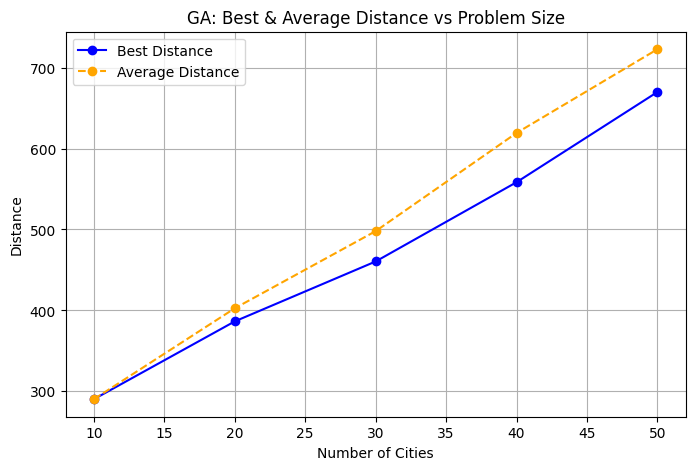

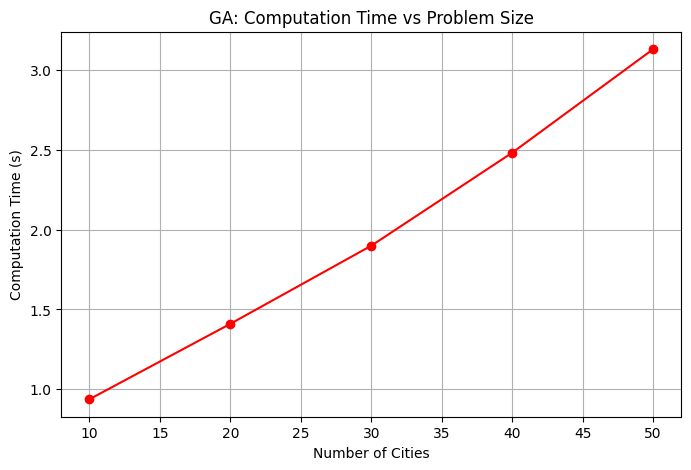

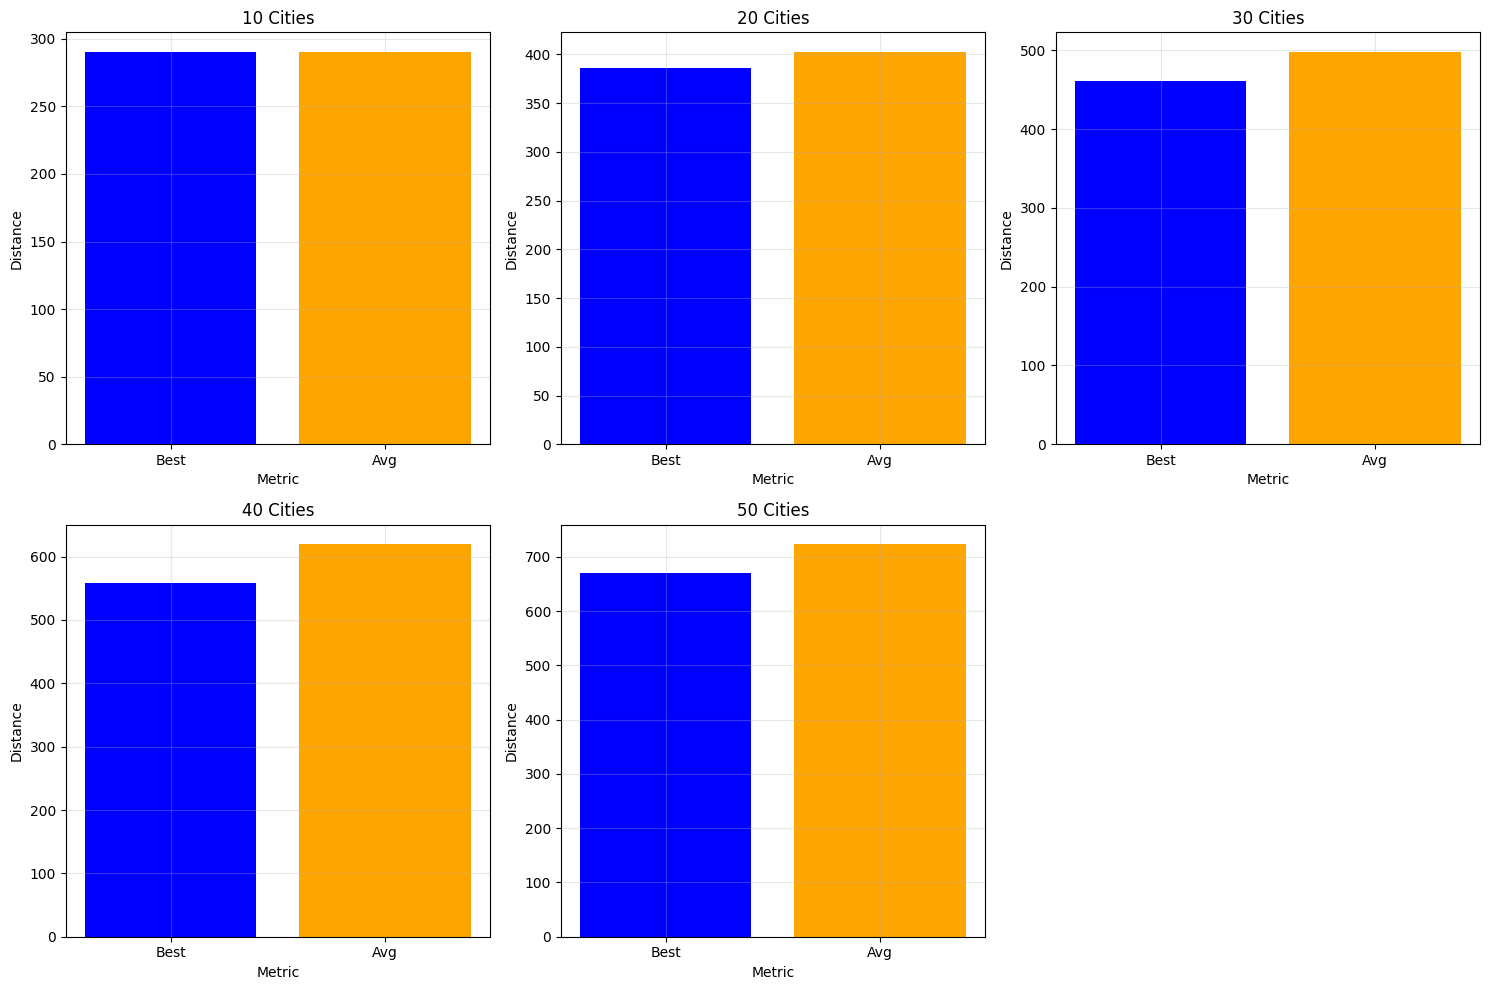


Scalability results saved to ga_scalability_results.txt


In [102]:
# ==============================
# Scalability Test: GA with Different City Sizes
# ==============================
P = 200
MUTRATE = 0.1
ELITE_SIZE = 2  # ADD THIS!
maxGeneration = 500
NUM_RUNS = 10  # number of independent GA runs per city size

CITY_SIZES = [10, 20, 30, 40, 50]
scalability_results = []

for size in CITY_SIZES:
    coords_subset = coords[:size]
    N = size
    # Recompute distance matrix for this city subset
    dist_matrix = np.sqrt(((coords_subset[:, None, :] - coords_subset[None, :, :]) ** 2).sum(axis=2))

    best_distances = []
    avg_distances = []
    run_times = []
    best_routes = []
    all_time_bests = []  # Track all-time best for each run

    for run in range(NUM_RUNS):
        # Initialize population
        population = [Individual(random.sample(range(N), N)) for _ in range(P)]
        for ind in population:
            ind.fitness = total_distance(ind)
        
        all_time_best = None
        all_time_best_fitness = float('inf')

        start_time = time.time()

        # Run GA evolution (USE CORRECT LOGIC)
        for gen in range(maxGeneration):
            # 1. Evaluate population
            for ind in population:
                ind.fitness = total_distance(ind)
            
            # 2. Track all-time best
            current_best = min(population, key=lambda x: x.fitness)
            if current_best.fitness < all_time_best_fitness:
                all_time_best = copy.deepcopy(current_best)
                all_time_best_fitness = current_best.fitness
            
            # 3. Extract elites
            elites = sorted(population, key=lambda x: x.fitness)[:ELITE_SIZE]
            elites = [copy.deepcopy(e) for e in elites]
            
            # 4. Selection (do NOT include elites)
            parents = selection(population, elite_size=0)
            
            # 5. Crossover → offspring
            offspring = crossover(parents)
            
            # 6. Mutation
            offspring = mutation(offspring, MUTRATE)
            
            # 7. Evaluate offspring
            for ind in offspring:
                ind.fitness = total_distance(ind)
            
            # 8. Insert elites back
            offspring_sorted = sorted(offspring, key=lambda x: x.fitness)
            offspring_sorted[-ELITE_SIZE:] = elites
            
            # 9. New population
            population = offspring_sorted

        end_time = time.time()
        computation_time = end_time - start_time
        run_times.append(computation_time)

        # Use all-time best, not final generation best
        final_distance = all_time_best_fitness if all_time_best else float('inf')
        best_distances.append(final_distance)
        best_routes.append(all_time_best.gene if all_time_best else [])
        all_time_bests.append(all_time_best)

    # Compute statistics for this city size
    mean_distance = np.mean(best_distances)
    best_index = np.argmin(best_distances)
    best_overall = best_distances[best_index]
    best_route = best_routes[best_index] if best_routes[best_index] else []
    best_solution_obj = all_time_bests[best_index]
    mean_time = np.mean(run_times)

    scalability_results.append({
        "Problem Size": size,
        "Best Distance": best_overall,
        "Average Distance": mean_distance,
        "Computation Time (s)": mean_time,
        "Best Route": best_route,
        "Best Solution Object": best_solution_obj
    })

# ==============================
# Display scalability results
# ==============================
results_df = pd.DataFrame(scalability_results)
print("\nScalability Test Results:")
print(results_df[["Problem Size", "Best Distance", "Average Distance", "Computation Time (s)"]].to_string(index=False, float_format="%.2f"))

# ==============================
# Plot Best & Average Distance vs Problem Size
# ==============================
plt.figure(figsize=(8,5))
plt.plot(results_df["Problem Size"], results_df["Best Distance"], marker='o', linestyle='-', color='blue', label='Best Distance')
plt.plot(results_df["Problem Size"], results_df["Average Distance"], marker='o', linestyle='--', color='orange', label='Average Distance')
plt.xlabel("Number of Cities")
plt.ylabel("Distance")
plt.title("GA: Best & Average Distance vs Problem Size")
plt.legend()
plt.grid(True)
plt.show()

# ==============================
# Plot Computation Time vs Problem Size
# ==============================
plt.figure(figsize=(8,5))
plt.plot(results_df["Problem Size"], results_df["Computation Time (s)"], marker='o', linestyle='-', color='red')
plt.xlabel("Number of Cities")
plt.ylabel("Computation Time (s)")
plt.title("GA: Computation Time vs Problem Size")
plt.grid(True)
plt.show()

# ==============================
# Optional: Plot convergence for each city size
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, size in enumerate(CITY_SIZES):
    if idx < len(axes):
        # You would need to track convergence during runs for this
        # For now, just mark the best distance
        result = scalability_results[idx]
        axes[idx].bar(['Best', 'Avg'], [result['Best Distance'], result['Average Distance']], 
                     color=['blue', 'orange'])
        axes[idx].set_xlabel('Metric')
        axes[idx].set_ylabel('Distance')
        axes[idx].set_title(f'{size} Cities')
        axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(CITY_SIZES), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# ==============================
# Save scalability results to text file
# ==============================
with open("../results/ga_scalability_results.txt", "w") as f:
    f.write("Scalability Test: GA with Different City Sizes\n")
    f.write("=============================================\n\n")
    f.write(f"Parameters: P={P}, MUTRATE={MUTRATE}, ELITE_SIZE={ELITE_SIZE}, Generations={maxGeneration}\n")
    f.write(f"Number of runs per city size: {NUM_RUNS}\n\n")
    
    for result in scalability_results:
        f.write(f"Number of Cities: {result['Problem Size']}\n")
        f.write(f"Best Distance: {result['Best Distance']:.2f}\n")
        f.write(f"Average Distance: {result['Average Distance']:.2f}\n")
        f.write(f"Average Computation Time (s): {result['Computation Time (s)']:.2f}\n")
        f.write("Best Route (city indices in order):\n")
        if result['Best Route']:
            f.write(" -> ".join(map(str, result['Best Route'])) + "\n\n")
        else:
            f.write("No valid route found\n\n")

print("\nScalability results saved to ga_scalability_results.txt")

### Scalability Test Result

#### Small Problem Sizes (10 and 20 cities)

- **For 10 cities**: Best distance (290.31) equals average distance, indicating the GA consistently finds the same high-quality solution across all 10 runs. The algorithm achieves perfect consistency for this problem size.

- **For 20 cities**: A divergence emerges between best (386.43) and average (402.61) distances, showing 4.2% variability. This indicates the GA begins to struggle with consistency as problem complexity increases, though still finds reasonably good solutions.

#### Medium Problem Sizes (30 and 40 cities)

**For 30 cities**: 
- Best distance = 460.46
- Average distance = 497.92 (8.1% worse than best)
- The significant gap demonstrates increasing difficulty in maintaining solution consistency.

**For 40 cities**:
- Best distance = 558.36  
- Average distance = 619.21 (10.9% worse than best)
- The consistency gap stabilizes but remains substantial, indicating the GA's stochastic nature becomes more pronounced.

The widening best-average gap shows the GA's sensitivity as search space complexity grows exponentially.

#### Large Problem Sizes (50 cities)

The consistency challenge intensifies:
- Best distance = 669.83
- Average distance = 722.63 (17.9% worse than best)
- This substantial 16.7% gap indicates the GA struggles to consistently find high-quality solutions for larger TSP.

#### Computational Performance Analysis

**Computation Time Growth**:
- 10 cities: 0.94 seconds
- 20 cities: 1.41 (+50%)
- 30 cities: 1.90 seconds (+34.8%)
- 40 cities: 2.48 seconds (+30.5%)
- 50 cities: 3.13 seconds (+26.2%)

The increase of the computation time demonstrates that it requires more power as problem size increases. 

#### Graph Interpretation

1. **Distance vs Problem Size**: The widening gap between best and average distances visually illustrates the GA's decreasing consistency with problem scale. The near-linear increase in both metrics suggests polynomial time complexity.

2. **Time vs Problem Size**: The approximately linear time growth confirms the GA's practical scalability, with computation time increasing modestly relative to problem size expansion.

# Algorithm Comparison

## Solution Quality Comparison 

| Metric | Iterated Local Search (ILS) | Genetic Algorithm (GA) | Winner |
|--------|----------------------------|------------------------|--------|
| **Best Distance (50 cities)** | 559.86 | 648.04 | **ILS** |


**Analysis**: ILS demonstrates significantly better solution quality with a better best performance (559.86 vs 648.04).

## Computational Performance Comparison

| Metric | Iterated Local Search (ILS) | Genetic Algorithm (GA) | Winner |
|--------|----------------------------|------------------------|--------|
| **Single Run Time (50 cities)** | 1.62 seconds | 2.54 seconds | **ILS** |

**Analysis**: ILS is computationally more efficient for smaller problem sizes. While GA shows comparable total time for multiple runs, ILS achieves better solutions faster, especially as problem size increases.

## Scalability Comparison

| Problem Size | ILS Best Distance | GA Best Distance | ILS Time | GA Time |
|--------------|-------------------|------------------|----------|---------|
| **10 cities** | 290.31 | 290.31 | 0.05s | 0.94s |
| **20 cities** | 386.43 | 386.43 | 0.09s | 1.41s |
| **30 cities** | 451.77 | 460.46 | 0.26s | 1.90s |
| **40 cities** | 490.39 | 558.36 | 0.72s | 2.48s |
| **50 cities** | 559.86 | 669.83 | 1.39s | 3.13s |

**Key Observations**:
- Small problems (≤20 cities): Both algorithms find similar optimal solutions, but ILS is 10 to 15 times faster
- Medium problems (30-40 cities): ILS maintains better solution quality with moderate time increase
- Large problems (50 cities): ILS outperforms GA in both solution quality (559.86 vs 669.83) and speed (1.39s vs 3.13s)

### **Robustness and Consistency Comparison**

| Metric | Iterated Local Search (ILS) | Genetic Algorithm (GA) | Winner |
|--------|----------------------------|------------------------|--------|
| **Standard Deviation (10 runs)** | **1.64** | 50.74 | **ILS** |
| **Best Distance Achieved (# of runs)** | **7 out of 10** | 1 out of 10 | **ILS** |
| **Mean Distance (10 runs)** | **560.92** | 758.32 | **ILS** |

**Analysis**: 
- ILS demonstrates exceptional consistency with a standard deviation of only 1.64, indicating high quality solutions. The algorithm found the best distance (559.86) in 7 out of 10 runs.
- The GA shows high variability with a standard deviation of 50.74, reflecting its sensitivity to initial populations. It achieved its best distance only once across 10 runs.
- The 30x lower standard deviation of ILS (1.64 vs 50.74) makes it more reliable.

## Recommendation

For the Traveling Salesman Problem with 50 cities:

**Primary Choice**: **Iterated Local Search (ILS)**
- Reasons:
  1. 15.7% better solution quality (559.86 vs 648.04)
  2. 45% faster single run execution (1.62s vs 2.54s)
  3. 7x higher success rate for achieving best distance (7 vs 1 runs)
  4. 30x more consistent performance (std dev 1.64 vs 50.74)
  5. Better time-quality tradeoff
  6. Simpler parameter tuning



